In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Checkpoint-2/data/da_sales_transactions.csv")

df["Revenue"] = (
    df["Units"]
    * df["Unit_Price"]
    * (1 - df["Discount_Pct"] / 100)
)

df.head()


,Transaction_ID,Date,Customer_ID,Product_ID,Category,Units,Unit_Price,Discount_Pct,Channel,City,Return_Flag,Revenue
0,T1,2025-01-24,C2,P2,Sports,5,539,15,Marketplace,Pune,1,2290.75
1,T2,2025-12-15,C3,P3,Grocery,1,4228,5,Marketplace,Delhi,0,4016.60
2,T3,2025-10-11,C4,P4,Books,2,2061,15,Offline,Chennai,0,3503.70
3,T4,2025-04-24,C5,P5,Electronics,3,2164,0,Website,Chennai,0,6492.00
4,T5,2025-06-25,C6,P6,Apparel,1,2341,0,Website,Kolkata,0,2341.00


# Week 4 Day 1 - Descriptive Statistics

## Objective

This analysis calculates descriptive statistics for retail revenue and examines the distribution of revenue across sales channels.

The analysis covers:

- Mean, median, mode
- Variance and standard deviation
- Frequency distribution
- Distribution shape
- Percentiles and quartiles
- Side-by-side box plots for comparing groups

In [2]:
revenue = df["Revenue"].dropna()

mean_value = revenue.mean()
median_value = revenue.median()
mode_value = revenue.mode().iloc[0]
variance_value = revenue.var()
std_value = revenue.std()

print("Mean:", round(mean_value, 2))
print("Median:", round(median_value, 2))
print("Mode:", round(mode_value, 2))
print("Variance:", round(variance_value, 2))
print("Standard Deviation:", round(std_value, 2))

Mean: 8021.85
Median: 6503.1
Mode: 4810.0
Variance: 30384293.76
Standard Deviation: 5512.2


In [3]:
revenue = df["Revenue"].dropna()

mean_value = revenue.mean()
median_value = revenue.median()
mode_value = revenue.mode().iloc[0]
variance_value = revenue.var()
std_value = revenue.std()

print("Mean:", round(mean_value, 2))
print("Median:", round(median_value, 2))
print("Mode:", round(mode_value, 2))
print("Variance:", round(variance_value, 2))
print("Standard Deviation:", round(std_value, 2))

Mean: 8021.85
Median: 6503.1
Mode: 4810.0
Variance: 30384293.76
Standard Deviation: 5512.2


In [4]:
p10 = revenue.quantile(0.10)
q1 = revenue.quantile(0.25)
q2 = revenue.quantile(0.50)
q3 = revenue.quantile(0.75)
p90 = revenue.quantile(0.90)

print("10th Percentile:", round(p10, 2))
print("Q1:", round(q1, 2))
print("Q2 (Median):", round(q2, 2))
print("Q3:", round(q3, 2))
print("90th Percentile:", round(p90, 2))
print("IQR:", round(q3 - q1, 2))

10th Percentile: 1951.2
Q1: 3617.5
Q2 (Median): 6503.1
Q3: 12162.1
90th Percentile: 16289.62
IQR: 8544.6


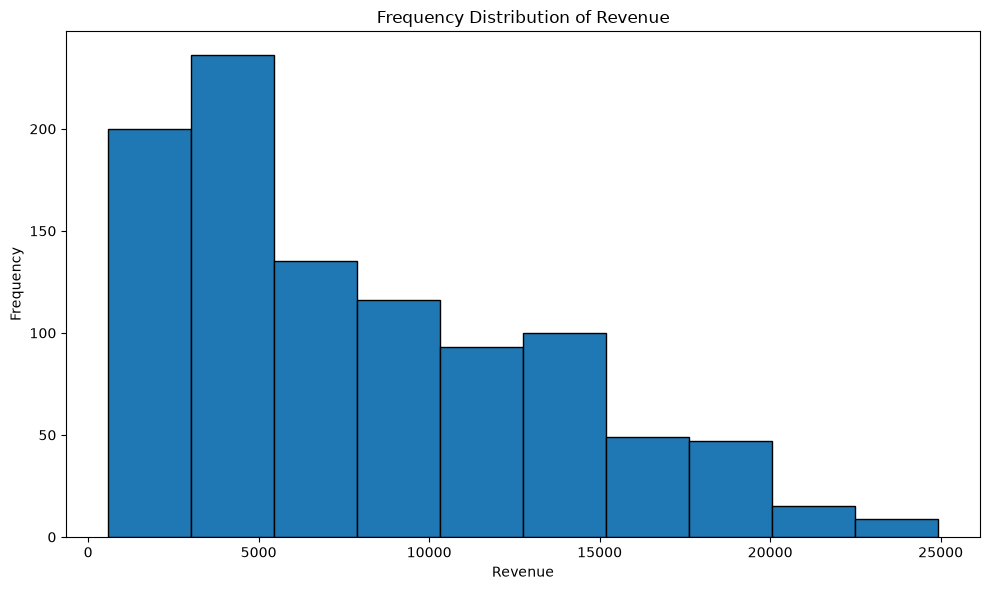

In [5]:
plt.figure(figsize=(10, 6))

plt.hist(
    revenue,
    bins=10,
    edgecolor="black"
)

plt.title("Frequency Distribution of Revenue")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.tight_layout()

plt.show()

### Distribution Interpretation

The revenue distribution is **right-skewed** because the skewness is approximately 0.76.

This indicates that most revenue values are concentrated toward the lower and middle range, with some higher-value transactions extending the distribution toward the right.

In [6]:
df["Channel"].value_counts()

Channel
Marketplace    255
App            250
Website        249
Offline        246
Name: count, dtype: int64

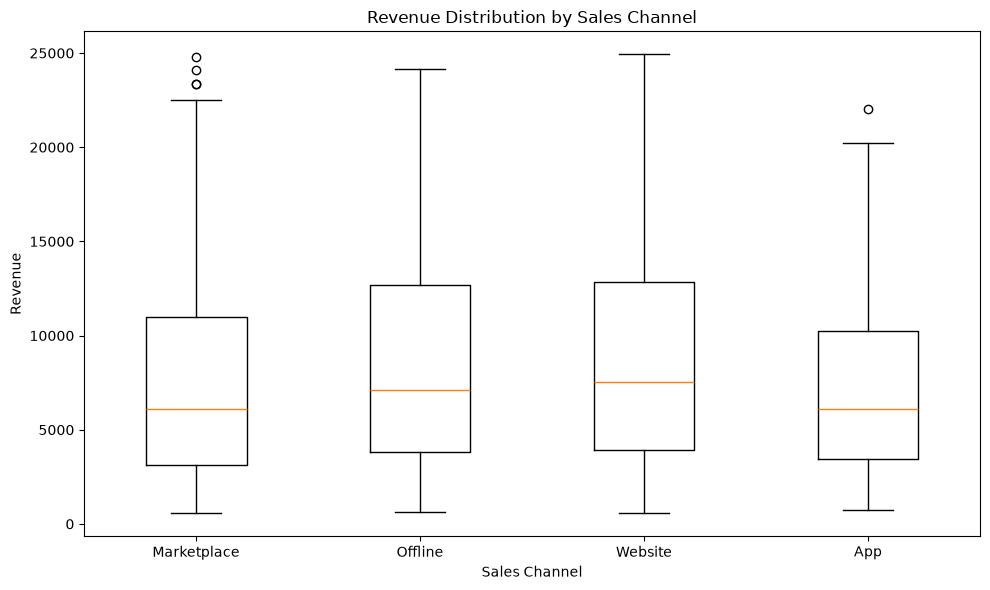

In [7]:
channels = df["Channel"].dropna().unique()

boxplot_data = [
    df.loc[df["Channel"] == channel, "Revenue"].dropna()
    for channel in channels
]

plt.figure(figsize=(10, 6))

plt.boxplot(
    boxplot_data,
    tick_labels=channels
)

plt.title("Revenue Distribution by Sales Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Revenue")
plt.tight_layout()

plt.show()

### Box Plot Interpretation

The box plot compares the distribution of revenue across Marketplace, App, Website, and Offline sales channels.

The median line inside each box represents the typical revenue level for that channel. The size of each box represents the interquartile range (IQR), showing the spread of the middle 50% of revenue values.

The whiskers and any points beyond them help identify the overall spread and potential outliers. Differences in the median and spread across channels indicate that revenue behavior varies between sales channels.

# Conclusion

The descriptive statistics show that the average revenue is affected by the presence of higher-value transactions.

The median revenue is ₹6,503.10, while the mean is higher, indicating that larger transactions influence the average.

The standard deviation of ₹5,512.20 shows substantial variation in transaction revenue.

The skewness value of 0.76 indicates a right-skewed distribution, meaning that higher-value transactions extend the distribution toward the right.

The quartiles show that the middle 50% of revenue values fall between ₹3,617.50 and ₹12,162.10, with an IQR of ₹8,544.60.

The box plot allows revenue distributions to be compared across Marketplace, App, Website, and Offline channels and helps identify differences in central tendency, spread, and potential outliers.